<img style="float: left;" class="center" width="200px" height="200px"
src="https://web.njit.edu/~sjyu/download/eovsa/OVSAs_logo.svg">


# Introduction

**Welcome to the practical workspace of EOVSA data analysis!**


This platform is a Google Colaboratory (Colab), a free Jupyter notebook environment that requires no setup and runs entirely in the cloud. This workspace provides the cells with the explanatory text and executable code for analysing an already calibrated EOVSA data.

We use an M4 class flare on 07 May 2021, around 19:00 UT occurred near the solar east limb as viewed from Earth, and was well observed by Solar Orbiter (including the STIX instrument). For other recent EOVSA events, [check here](http://www.ovsa.njit.edu/wiki/index.php/Recent_Flare_List_(2021)).

---

<p><a href="http://ovsa.njit.edu/browser/?suntoday_date=2021-05-07">
<img style="float: right;" width="600px" src="https://web.njit.edu/~gary/EOVSA_20210507_M4flare.png"></a></p>

*Figure 1: Dynamic spectrum and lightcurves for the 2021 May 07 M4 flare*

---

# Test the Colab cells

Go ahead and edit the command cell given below with your own text and click the play icon (run) button by hovering on the square paranthesis at the left side of the cell.

In [ ]:
print ("Hello Sun!")

Hello Sun!


# Software Requirements





* As discussed in the Wiki tutorial, EOVSA data processing and analysis are developed over SunCASA and GSFIT IDL packages.

* For this tutorial, we will demonstrate using **SunCASA** to create EOVSA image and spectrogram from the observed visibility data. If you desire to install the SunCASA package on your own machine as in [this section](http://ovsa.njit.edu//wiki/index.php/EOVSA_Data_Analysis_Tutorial_2022#Installation_of_SunCASA_(optional)) of the Wiki tutorial, visit back to this workspace from [Step 4](https://colab.research.google.com/drive/19NQb6Emb9HvKX4QHq9ZYCP3RM6nT7sDL#scrollTo=X4Sbgw834uqW) onwards for EOVSA data analysis.


# A Brief Tour to Suncasa

We recommend you to use Google Chrome browser to run the notebook.
Let's first perform a sanity check if suncasa is properly installed.

## Step 1: Check the python version in the runtime first.
> CASA software is compatible with multiple versions of Python (<=3.8). Please refer to the [Compatibility Matrix](https://casadocs.readthedocs.io/en/latest/notebooks/introduction.html#Compatibility) for detailed information on the Operating Systems and Python versions expected to work with current and future versions of CASA.




In [ ]:
!python --version

Python 3.10.12


In [ ]:
import sys
sys.path

['/content',
 '/env/python',
 '/usr/lib/python310.zip',
 '/usr/lib/python3.10',
 '/usr/lib/python3.10/lib-dynload',
 '',
 '/usr/local/lib/python3.10/dist-packages',
 '/usr/lib/python3/dist-packages',
 '/usr/local/lib/python3.10/dist-packages/IPython/extensions',
 '/usr/local/lib/python3.10/dist-packages/setuptools/_vendor',
 '/root/.ipython']

In [ ]:
import matplotlib
matplotlib.__file__

'/usr/local/lib/python3.10/dist-packages/matplotlib/__init__.py'

## Step 2: Install pip for the new python

## Step 3: Install SunCASA

In [ ]:
import os, sys

try:
    import suncasa
    print('Suncasa is already installed!')
except:
    ## The step will keep suncasa up-to-date.
    res = os.system("pip install --upgrade suncasa")
    if res == 0:
        print('Suncasa installation successful!')
    else:
        print('Suncasa installation unsuccessful. Abort...')


Suncasa is already installed!


In [ ]:
!pip install --upgrade suncasa==1.0.8.2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 19.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for suncasa: filename=suncasa-1.0.8.2-py3-none-any.whl size=629743 sha256=5207f39386076e6555a67d8c868253dda1a8e629cb04acba44e7c345eb9eed18
  Stored in directory: /root/.cache/pip/wheels/65/a2/cc/e30b5f0afce997780d28268202cc24668a3ae2b7310126dc96
Successfully built suncasa
  Attempting uninstall: suncasa
    Found existing installation: suncasa 1.0.8.1
    Uninstalling suncasa-1.0.8.1:
      Successfully uninstalled suncasa-1.0.8.1


The following code creates a configuration file to define the EOVSA instrument so that CASA is aware of it. We plan to add EOVSA officially to the CASA distribution in the future, after which this step is not necessary.

In [ ]:
print("building config file...")
import os
homedir = os.path.expanduser('~/.casa')
if not os.path.exists(homedir):
    os.system("mkdir {}".format(homedir))
with (open(os.path.join(homedir,'config.py'), 'w')) as fi:
    fi.write("import sys \n")
    fi.write("import os \n")
    fi.write("import sysconfig \n")
    fi.write("import casatools \n")
    fi.write("import casadata \n")
    fi.write("import time \n")
    fi.write("logfile='casalog-{}.log'.format(time.strftime('%Y%m%d-%H',time.localtime())) \n")
    fi.write("telemetry_enabled = False \n")
    fi.write("crashreporter_enabled = True \n")
    fi.write("tb=casatools.table() \n")
    fi.write("ospathsep = os.path.sep \n")
    fi.write("libpath = sysconfig.get_paths()['purelib'] \n")
    fi.write("obsdict = {'MJD': 57447.0, 'Name': 'EOVSA', 'Type': 'WGS84', 'Long': -118.287, \n")
    fi.write("            'Lat': 37.2332, 'Height': 1207.13, 'X': 0.0, 'Y': 0.0, 'Z': 0.0,  \n")
    fi.write("            'Source': 'Dale Gary'} \n")
    fi.write("obstable = os.path.join(casadata.datapath,'geodetic','Observatories') \n")
    fi.write("tb.open(obstable, nomodify=True) \n")
    fi.write("if 'EOVSA' not in tb.getcol('Name'): \n")
    fi.write("    print('Adding EOVSA to the Observatories') \n")
    fi.write("    tb.close() \n")
    fi.write("    tb.open(obstable, nomodify=False) \n")
    fi.write("    nrows = tb.nrows() \n")
    fi.write("    tb.addrows(1) \n")
    fi.write("    for k in obsdict.keys(): \n")
    fi.write("        tb.putcell(k, nrows, obsdict[k])     \n")
    fi.write("tb.close() \n")
    fi.close()

print('Config file is written successfully!')

building config file...
Config file is written successfully!


Use an interactive plotting backend when possible.

In [ ]:
# Install ipympl, which provides an interactive Matplotlib backend for Jupyter Notebooks
!pip install ipympl

# Enable the custom widget manager in Google Colab for interactive widgets
from google.colab import output
output.enable_custom_widget_manager()

# Use the widget backend for interactive plots
%matplotlib widget

---
---

>**Now, let us execute the analysis steps (from Step 4 onwards) as discussed in the [EOVSA Wiki tutorial](http://ovsa.njit.edu/wiki/index.php/EOVSA_Data_Analysis_Tutorial_2022).**

>**Here, we provide a calibrated and self-calibrated EOVSA visibility dataset in CASA ms format (IDB20210507_1840-1920XXYY.cal.10s.slfcaled.ms) which is ready for science analyses purposes**, as discussed in [this section](http://ovsa.njit.edu//wiki/index.php/EOVSA_Data_Analysis_Tutorial_2022#1._Introduction_to_EOVSA_and_Datasets)

The actual visibility data are stored in a main table that contains a number of rows, each of which is effectively a single timestamp for a single spectral window and a single baseline. In addition to everything already available in CASA, with SunCASA you have access to additional tools that allow you to explore and utilize the radio dynamic spectroscopic imaging data from EOVSA.

# Step 4: Download Sample EOVSA Data for the Tutorial

In [ ]:
msfile = 'IDB20210507_1840-1920XXYY.cal.10s.slfcaled.ms'
if not os.path.exists(msfile):
    print("downloading MeasurementSet from Web")
    !wget https://web.njit.edu/~sjyu/download/eovsa/eovsa_tutorial/rhessi2021/IDB20210507_1840-1920XXYY.cal.10s.slfcaled.ms.tar.gz
    os.system("tar -xvf IDB20210507_1840-1920XXYY.cal.10s.slfcaled.ms.tar.gz")
    print('Data are successfully downloaded.')
else:
    print('Measurement set already exists. Skipping download.')
# http://ovsa.njit.edu/fits/UDBms_slfcaled/202104/UDB20210417_1635-1700.ms.tar.gz


Measurement set already exists. Skipping download.


# Step 5: Information on the EOVSA Visibility Data (CASA Measurement Set)

* CASA tasks can be invoked using "import" as shown in the first line of the cell given below, while CASA tools are Python classes that first need to be instantiated to create usable objects.

* Let us first run a useful task "listobs", which provides a summary of the measurement set. It provides almost all relevant observational parameters such as correlator setup (frequencies, bandwidths, channel number and widths, polarization products), sources, scans, scan intents, and antenna locations.



In [ ]:
!pip install casatools
!pip install casatasks
!pip install casadata
!mkdir ~/.casa/data

mkdir: cannot create directory ‘/root/.casa/data’: File exists


For some reasons, the python 3.8 site-packages directory was not in the system path. Added it to sys.path on the fly

In [ ]:
from casatasks import listobs
import os
rc = listobs(vis = msfile, listfile = msfile + '.listobs', overwrite=True)

print(os.popen("cat " + msfile + ".listobs").read())

           MeasurementSet Name:  /content/IDB20210507_1840-1920XXYY.cal.10s.slfcaled.ms      MS Version 2
   Observer: EOVSA team     Project: NormalObserving  
Observation: EOVSA
Data records: 910000       Total elapsed time = 2022 seconds
   Observed from   07-May-2021/18:45:20.5   to   07-May-2021/19:19:02.5 (UTC)

   ObservationID = 0         ArrayID = 0
  Date        Timerange (UTC)          Scan  FldId FieldName             nRows     SpwIds   Average Interval(s)    ScanIntent
  07-May-2021/18:45:20.5 - 18:55:20.5     0      0 Sun                     273000  [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49]  [10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10] 
              18:55:20.5 - 19:05:20.5     1      0 Sun                     273000  [0

* Next, we will look at a graphical plot of the locations of EOVSA's 13 antennas using the CASA "plotants" task (see the figure below).

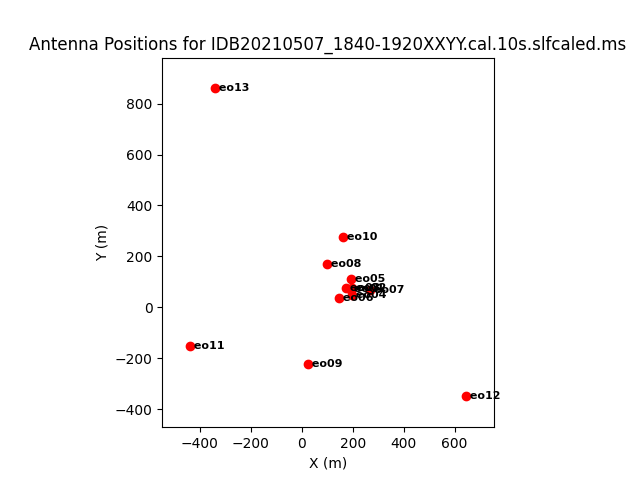

In [ ]:
from casatasks import plotants
import matplotlib.pyplot as plt
plotants(vis = msfile)
ax=plt.gca()
ax.set_aspect('equal')

# Step 7: Cross-Power Dynamic Spectrum


The first module we introduce is [`dspec`](https://github.com/suncasa/suncasa-src/blob/master/suncasa/utils/dspec.py). This module generates a cross-power dynamic spectrum from a ms file, and visualize it. You can select a subset of data by specifying a [time range](https://casa.nrao.edu/Release3.3.0/docs/UserMan/UserMansu112.html), [spectral windows/channels](https://casaguides.nrao.edu/index.php/Selecting_Spectral_Windows_and_Channels), [antenna baseline](https://casaguides.nrao.edu/index.php/Antenna/Baseline_Selection_Syntax_with_or_without_Autocorrelations), or [uvrange](https://casa.nrao.edu/Release3.3.0/docs/UserMan/UserMansu113.html). The selection syntax follows the CASA convention. More information of CASA selection syntax may be found in the above links or the [Measurement Selection Syntax](https://casa.nrao.edu/casadocs/casa-5.4.0/data-selection/data-selection-in-a-measurementset) documentation.

Using DATA column
selecting two baselines: (2, 1, 451, 200)
ploting dynamic spectrum...
(2, 1, 451, 200)


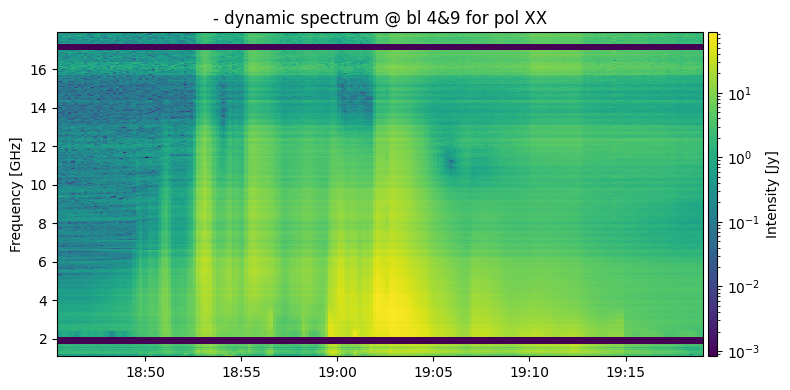

In [ ]:
from suncasa import dspec as ds
import time
import numpy as np
    # The example below shows the cross-power spectrogram from a baseline selected using the parameter "bl".
    # bl = '4&9' means selecting a baseline from Antenna ID 4 (Antenna Name "eo05") correlating with Antenna ID 9 (Antenna Name "eo10") - refer listobs output.
    # you can also use the "bl" parameter to select multiple baseline(s), i.e., bl='0&2;4&9;8&11'.
specfile = msfile + '.dspec.npz'
    # Hover over "Dspec" in the next line to see additional arguments or use help(ds.Dspec)
d = ds.Dspec()
d.get_dspec(msfile, specfile=specfile, bl='4&9')
print('selecting two baselines:', d.data.shape)
d.plot(vmin=None, vmax=None, pol='XX')
print(d.data.shape) # The shape gives the dimensions of polarization, baselines, frequencies, time

Additionally, "dspec" accepts dynamic spectrum data (specfile) as input directly.

ploting dynamic spectrum...
(2, 1, 451, 200)


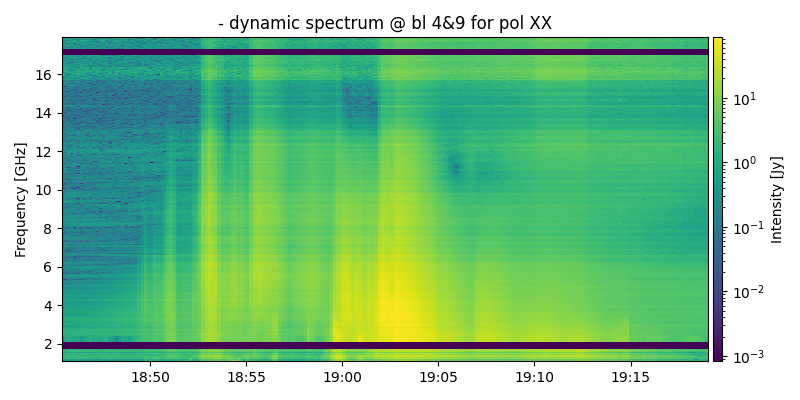

In [ ]:
d = ds.Dspec(specfile)
d.plot(vmin=None, vmax=None, pol='XX')
print(d.data.shape) # npol, nbl, nfreq, ntime

---
* "dspec" also works with the EOVSA All-day total power spectrum fits data product, which can be downloaded from [EOVSA browser](http://ovsa.njit.edu/browser/?suntoday_date=2021-05-07). The TP spectrum includes the background solar disk flux density, which grows from about 100 sfu at 1 GHz to >500 sfu at 18 GHz.

--2024-11-11 04:20:25--  https://ovsa.njit.edu/fits/synoptic/2021/05/07/EOVSA_TPall_20210507.fts
Resolving ovsa.njit.edu (ovsa.njit.edu)... 192.100.16.206
Connecting to ovsa.njit.edu (ovsa.njit.edu)|192.100.16.206|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 65571840 (63M)
Saving to: ‘EOVSA_TPall_20210507.fts’

EOVSA_TPall_2021050 100%[===================>]  62.53M   419KB/s    in 2m 14s  

2024-11-11 04:22:40 (477 KB/s) - ‘EOVSA_TPall_20210507.fts’ saved [65571840/65571840]

Data are successfully downloaded.
ploting dynamic spectrum...


/usr/local/lib/python3.10/dist-packages/suncasa/dspec/dspec.py:1254: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  im = ax.pcolormesh(tim_plt, freq_plt, spec_plt, cmap=cmap, norm=norm, shading='auto',


(451, 36180)


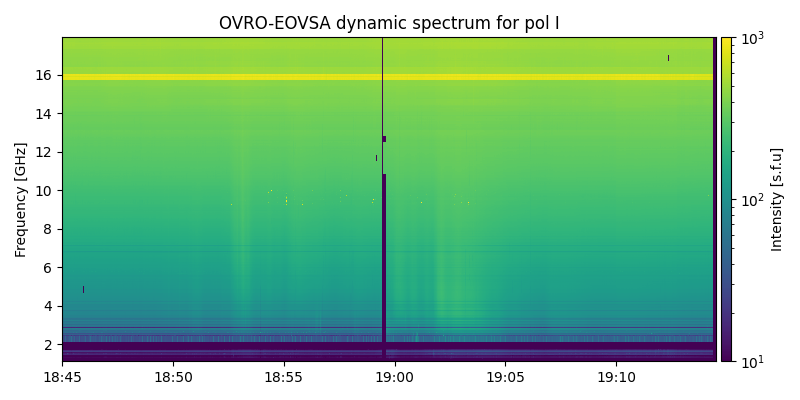

In [ ]:
tpfile = 'EOVSA_TPall_20210507.fts'
if not os.path.exists(tpfile):
    !wget https://ovsa.njit.edu/fits/synoptic/2021/05/07/EOVSA_TPall_20210507.fts
    print('Data are successfully downloaded.')
else:
    print('Total Power Dynamic Spectrum data already exists. Skipping download.')
from matplotlib.colors import LogNorm
    ## load the total power data and plot it
d_tp = ds.Dspec()
d_tp.read(tpfile, source='eovsa')
d_tp.plot(norm=LogNorm(vmin=10,vmax=1000), timerange=['2021-05-07T18:45:00','2021-05-07T19:15:00'])

print(d_tp.data.shape) #Dimensions of frequencies and time


# Step 8: Quick-Look Imaging



* Now, let us start using the task "qlookplot" to generate an observing summary plot of the cross-power dynamic spectrum, GOES light curves and EOVSA quick-look images.
* The parameters below create a quick-look EOVSA image with a 10-s integration at 19:02 UT using spectral window IDs 2 to 5 (bands 5 to 8, see above listobs output), which correspond to the frequency range of 2.4–3.7 GHz.

Imported CASA tasks from casatasks: split, tclean, casalog, clearcal, gaincal.
spw is ['12~19']
plot the dynamic spectrum in pol XX


Files Downloaded:   0%|          | 0/4 [00:00<?, ?file/s]

This is EOVSA data
do clean for 2021/05/07/18:53:30~2021/05/07/18:53:40 in spw 12~19 stokes XX
Original phasecenter: 0.77948273873719790.295749074341333
use phasecenter: J2000 0.7794827387371979rad 0.295749074341333rad
use restoringbeam 60arcsec
Warning!!! Only one record exists in the ms ephemeris record.
           I have to use this only record to register the image.
fits file EOVSA_20210507T185335.000000.image.fits selected


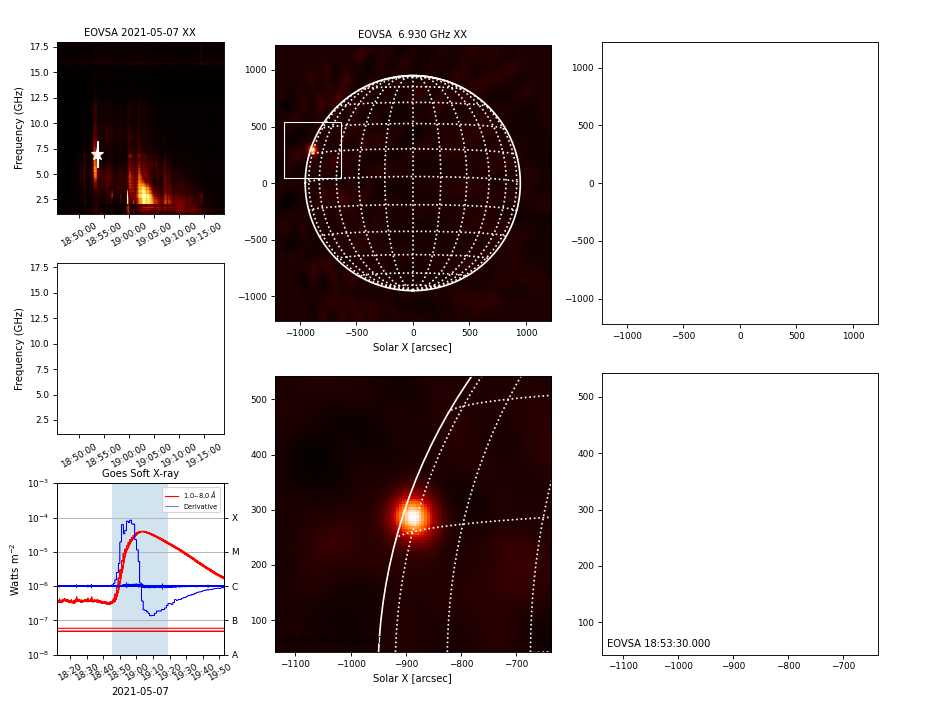

('EOVSA_20210507T185335.000000.image.fits', None, None)

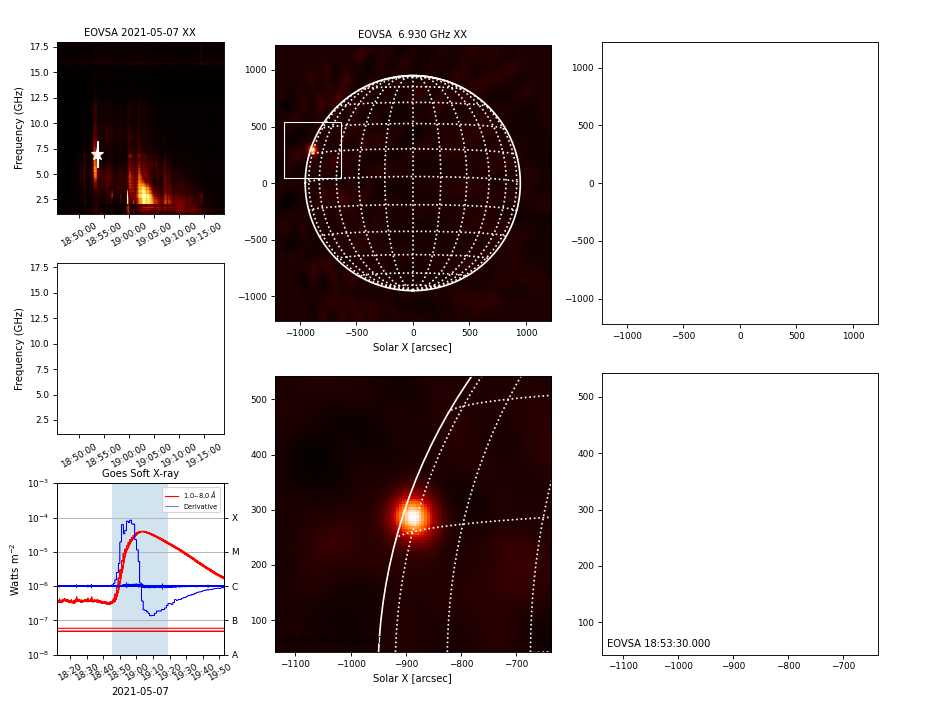

In [ ]:
from suncasa.utils import qlookplot as ql
timerange = '18:53:30~18:53:40'
spw = '12~19'
stokes = 'XX'
plotaia = False        ## Initially, turn off AIA image plotting, default is True
ql.qlookplot(vis=msfile, specfile=specfile, timerange=timerange, spw=spw, \
    stokes=stokes, plotaia=plotaia, restoringbeam=['60arcsec'], robust=0.5)

### Quick-look Imaging with AIA data

The default AIA passband is 171 A. Use the aiawave parameter (e.g. aiawave=94) to select a different passband.

Imported CASA tasks from casatasks: split, tclean, casalog, clearcal, gaincal.
spw is ['12~19']
plot the dynamic spectrum in pol XX


Files Downloaded:   0%|          | 0/4 [00:00<?, ?file/s]

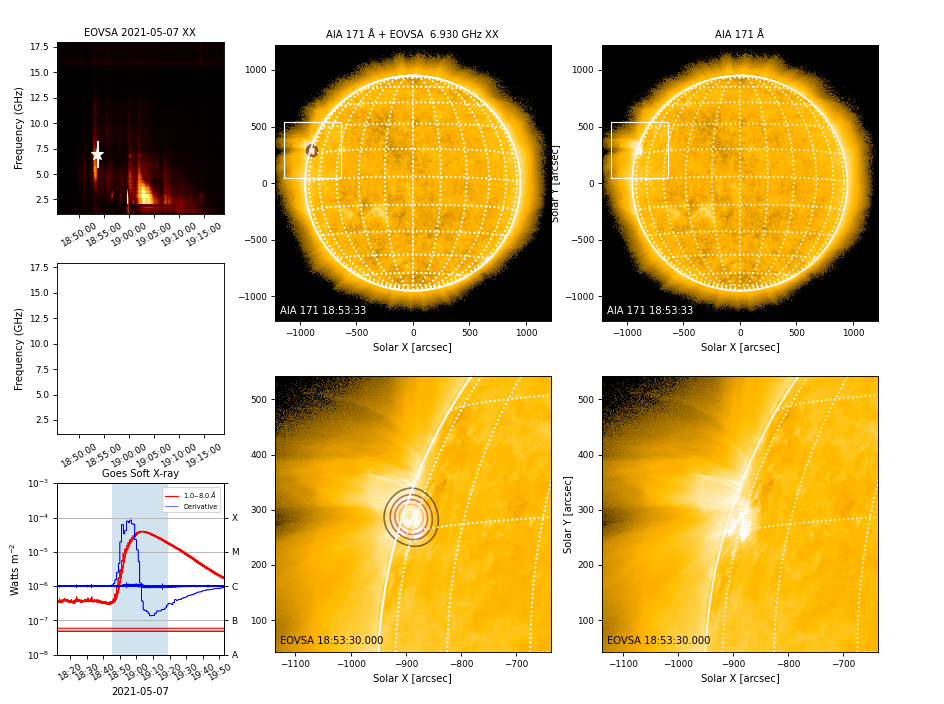

('EOVSA_20210507T185335.000000.image.fits', None, None)

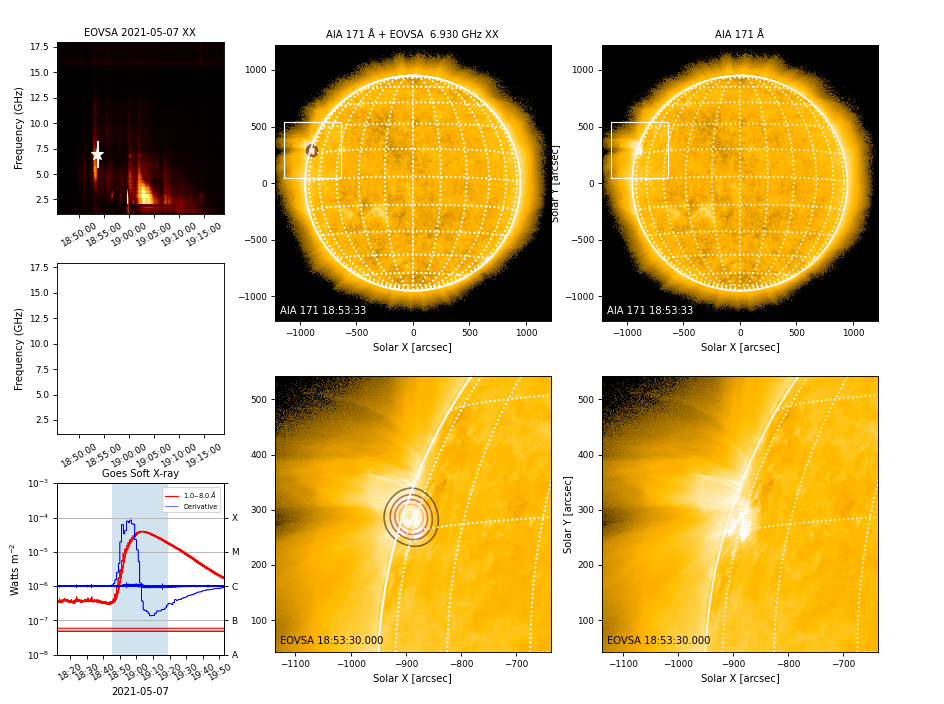

In [ ]:
overwrite = False     ## set overwrite=False to use the radio image from previous step.
outfits = 'EOVSA_20210507T185335.000000.image.fits'
plotaia = True
ql.qlookplot(vis=msfile, specfile=specfile, timerange=timerange, spw=spw, \
    stokes=stokes, plotaia=plotaia, outfits = outfits, overwrite=overwrite, \
    opencontour=True,
    restoringbeam=['60arcsec'],robust=0.5)

### Quick-look Imaging with AIA data and all spw

Imported CASA tasks from casatasks: split, tclean, casalog, clearcal, gaincal.
spw is ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47']
plot the dynamic spectrum in pol XX


Files Downloaded:   0%|          | 0/4 [00:00<?, ?file/s]

('EOVSA_20210507T185335.000000.outim.image.allbd.fits', None, None)

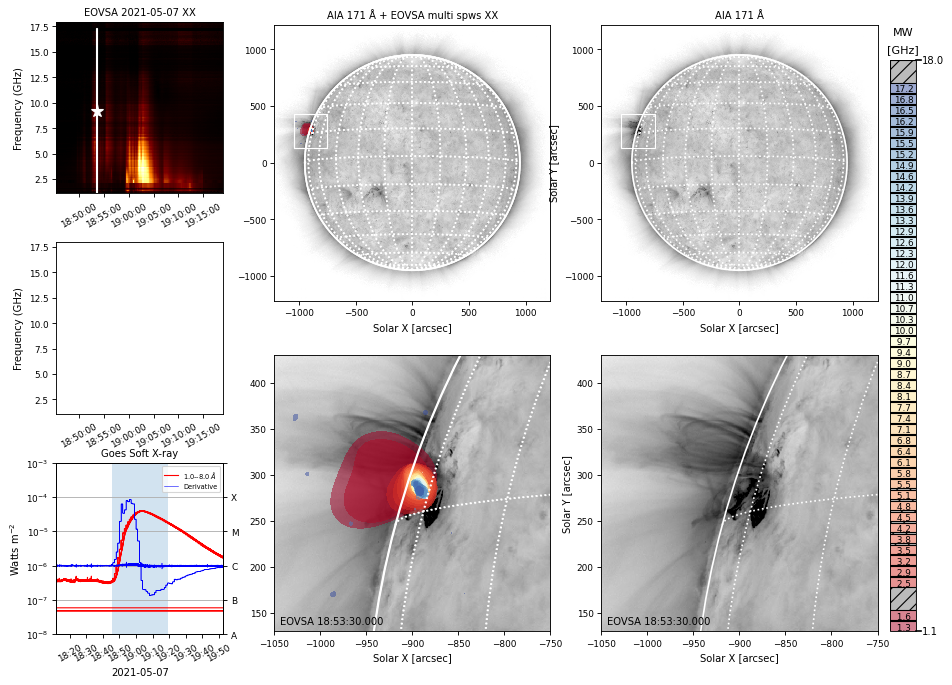

In [ ]:
from suncasa.utils.mstools import time2filename
from suncasa.utils import qlookplot as ql
# spw = [f'{l}~{l+1}' for l in range(0, 48,2)]    ## select (almost) all spectral windows from spw id #0 to #47
spw = [f'{l}' for l in range(0, 48)]    ## select (almost) all spectral windows from spw id #0 to #47
timerange = '18:53:30~18:53:40'
stokes = 'XX'
outfits = time2filename(msfile,timerange=timerange)+'.outim.image.allbd.fits'

xycen = [-900, 280]      ## image center for clean in solar X-Y in arcsec
cell=['2.0arcsec']       ## pixel scale
imsize=[128]             ## number of pixels in X and Y. If only one value is provided, NX = NY
fov = [300,300]          ## field of view of the zoomed-in panels in unit of arcsec
plotaia = True           ## turn on AIA image plotting
aiawave = 171           ## AIA passband in Å. The options are [171,131,304,335,211,193,94,1600,1700]
acmap = 'gray_r'         ## Choose the color map for AIA images. If not provided, the program will use default AIA colormap.
icmap = 'RdYlBu'

ql.qlookplot(vis=msfile, specfile=specfile, timerange=timerange,
             spw=spw, stokes=stokes, plotaia=plotaia, aiawave=aiawave,
             robust = 0.5, acmap=acmap,
             imsize=imsize,cell=cell,xycen=xycen,fov=fov,
             icmap=icmap,
             outfits=outfits,overwrite=False)

At high frequencies, the microwave source concentrates near the flare site, corresponding pretty well with the flare kernel in SDO/AIA. At low frequencies, the microwave source extends to higher altitudes in the corona.

# Downloading fits files to your local system


* Once you have produced the images, you may retrieve the output images to your local computer.

* Colab supports downloading one file at a time. For downloading multiple files or a folder, you can use a file compression utility such as [`tar`](https://manpages.ubuntu.com/manpages/xenial/en/man1/tar.1.html) to combine multiple files or folders into a compressed archive file.

* Run the following cell for downloading a compressed archive file (images.tar.gz) to your local computer after combining all the fits files (*.fits).

Try it!

In [ ]:
from google.colab import files
os.system('tar -cvzf eovsa_images.tar.gz *.fits')
files.download('eovsa_images.tar.gz')